In [1]:
# Import necessary libraries
import re
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Function to extract loss values from log lines
def extract_loss(log_lines):
    losses = []
    for line in log_lines:
        # Use regex to find the loss value in the line
        match = re.search(r'Train Epoch: \d+ \d+ ([\d.]+)', line)
        if match:
            loss = float(match.group(1))
            losses.append(loss)
    return losses

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [12]:
# Function to read log file and extract loss values
def read_log_file(file_path):
    with open(file_path, 'r') as file:
        log_lines = file.readlines()
    return np.array(extract_loss(log_lines))

log_file_path = 'exp_1/ml_multi_2-4.out' 
loss_4 = read_log_file(log_file_path)

log_file_path = 'exp_1/ml_multi_2-2.out' 
loss_2 = read_log_file(log_file_path)

log_file_path = 'exp_1/ml_multi_2-1.out' 
loss_1 = read_log_file(log_file_path)

In [4]:
print(
    len(loss_1)
)


62772


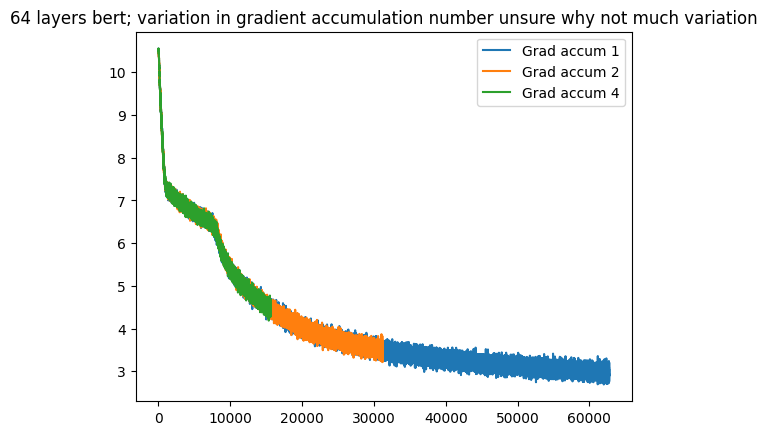

In [5]:
plt.plot(loss_1)
plt.plot(loss_2)
plt.plot(loss_4)
plt.title('64 layers bert; variation in gradient accumulation number unsure why not much variation')
plt.legend(['Grad accum 1', 'Grad accum 2', 'Grad accum 4'])
plt.show()

In [6]:
log_file_path = 'exp_2/ml_multi_2-4.out' 
loss_4 = read_log_file(log_file_path)

log_file_path = 'exp_2/ml_multi_2-2.out' 
loss_2 = read_log_file(log_file_path)

log_file_path = 'exp_2/ml_multi_2-1.out' 
loss_1 = read_log_file(log_file_path)

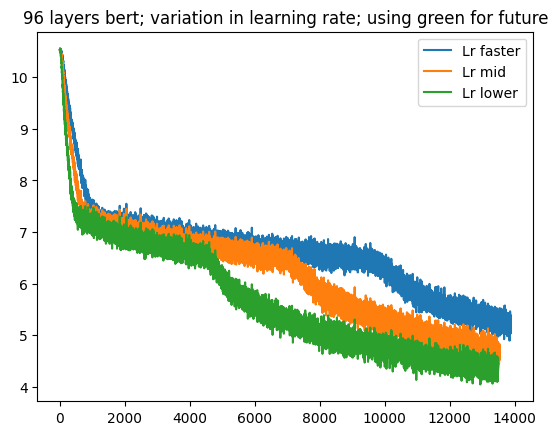

In [7]:
plt.plot(loss_1)
plt.plot(loss_2)
plt.plot(loss_4)
plt.title('96 layers bert; variation in learning rate; using green for future')
plt.legend(['Lr faster', 'Lr mid', 'Lr lower'])
plt.show()

In [8]:
log_file_path = 'exp_3/ml_multi_2-4.out' 
loss_4 = read_log_file(log_file_path)

log_file_path = 'exp_3/ml_multi_2-2.out' 
loss_2 = read_log_file(log_file_path)

log_file_path = 'exp_3/ml_multi_2-1.out' 
loss_1 = read_log_file(log_file_path)

log_file_path = 'exp_3/ml_multi_2-parallel.out' 
loss_8 = read_log_file(log_file_path)


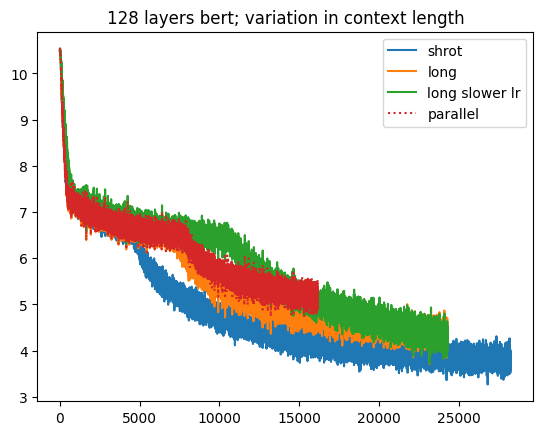

In [9]:
plt.plot(loss_1)
plt.plot(loss_2)
plt.plot(loss_4)
plt.plot(loss_8, linestyle='dotted')
plt.title('128 layers bert; variation in context length')
plt.legend(['shrot', 'long', 'long slower lr', 'parallel'])
plt.show()

In [37]:
log_file_path = 'exp_3/ml_multi_2-2.out' 
loss_serial = read_log_file(log_file_path)

log_file_path = 'exp_4/ml_multi_4.out' 
loss_parallel = read_log_file(log_file_path)

log_file_path = 'exp_4/ml_multi_4-continue.out'
loss_4 = read_log_file(log_file_path)

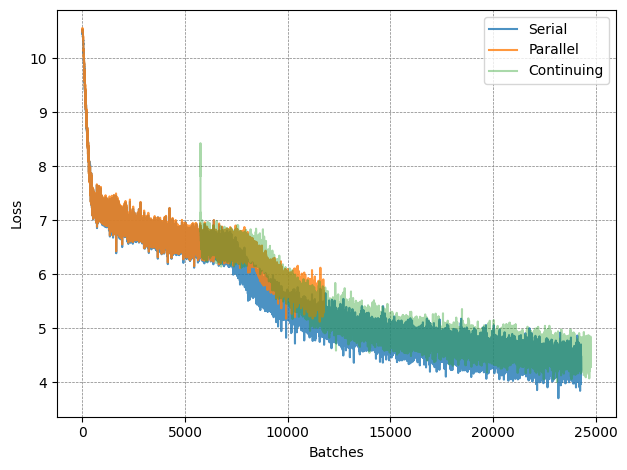

In [49]:
plt.plot(np.arange(len(loss_serial)), loss_serial, alpha=.8)
plt.plot(np.arange(len(loss_parallel)), loss_parallel, alpha=.8)
plt.plot(np.arange(len(loss_4[0:19000])) + 23000//4, loss_4[0:19000], alpha=.4)
# plt.title('128 Layers Bert')
plt.legend(['Serial', 'Parallel', 'Continuing'])
plt.xlabel('Batches')
plt.ylabel('Loss')
# Add grid with customization
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

[10.55311012 10.54605579 10.53832245 ...  4.37446308  4.19954729
  3.70499539]


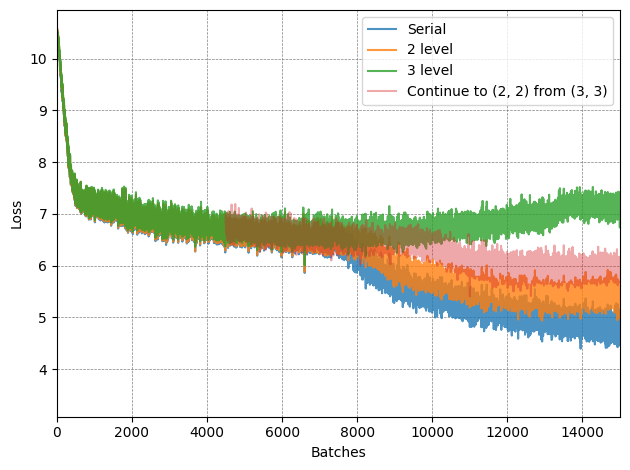

In [16]:
log_file_path = 'exp_5/ml_multi_4-serial.out' 
loss_serial = read_log_file(log_file_path)

log_file_path = 'exp_5/ml_multi_4-parallel.out' 
loss_parallel = read_log_file(log_file_path)

log_file_path = 'ml_multi_4-parallel-3.out' 
loss_parallel_2 = read_log_file(log_file_path)

log_file_path = 'ml_multi_4-3-continue.out'
loss_4 = read_log_file(log_file_path)

print(loss_serial)
plt.plot(np.arange(len(loss_serial)), loss_serial, alpha=.8)
plt.plot(np.arange(len(loss_serial)), loss_parallel[0:len(loss_serial)], alpha=.8)
plt.plot(np.arange(len(loss_parallel_2)), loss_parallel_2[0:len(loss_parallel_2)], alpha=.8)

offset = 4500
skip = 100
plt.plot(np.arange(offset, offset + len(loss_4[skip:])), loss_4[skip:], alpha=.4)
# plt.plot(np.arange(len(loss_4[0:19000])) + 23000//4, loss_4[0:19000], alpha=.4)
# plt.title('128 Layers Bert')
plt.legend(['Serial', '2 level', '3 level', 'Continue to (2, 2) from (3, 3)'])
plt.xlabel('Batches')
plt.ylabel('Loss')
# Add grid with customization
plt.grid(color='gray', linestyle='--', linewidth=0.5)

plt.xlim(0, 15000)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

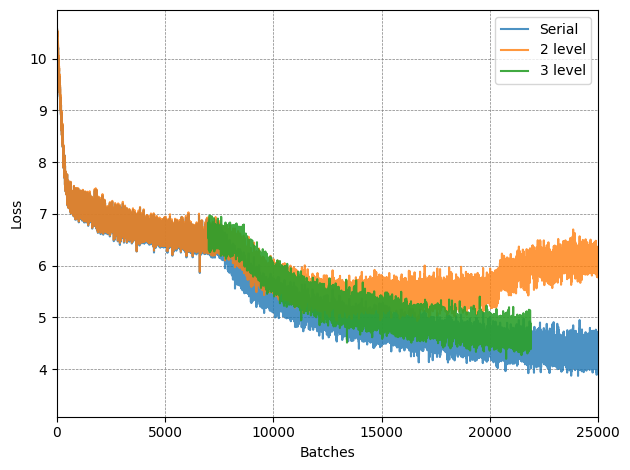

In [6]:
log_file_path = 'exp_5/ml_multi_4-serial.out' 
loss_serial = read_log_file(log_file_path)

log_file_path = 'exp_5/ml_multi_4-parallel.out' 
loss_parallel = read_log_file(log_file_path)

log_file_path = 'ml_multi_4-parallel-3.out' 
loss_parallel_33 = read_log_file(log_file_path)

# log_file_path = 'ml_multi_4-3-continue.out'
# loss_4 = read_log_file(log_file_path)

log_file_path = 'ml_multi_4-22-serial.out'
loss_continue_22 = read_log_file(log_file_path)

plt.plot(np.arange(len(loss_serial)), loss_serial, alpha=.8)
plt.plot(np.arange(len(loss_serial)), loss_parallel[0:len(loss_serial)], alpha=.8)
# plt.plot(np.arange(len(loss_parallel_2)), loss_parallel_33[0:len(loss_parallel_2)], alpha=.8)

# offset = 7000
# skip = 100
# plt.plot(np.arange(offset, offset + len(loss_continue_22[skip:])), loss_continue_22[skip:], alpha=.4)

offset = 7000
skip = 200
plt.plot(np.arange(offset, offset + len(loss_continue_22[skip:])), loss_continue_22[skip:], alpha=.9)

# plt.plot(np.arange(len(loss_4[0:19000])) + 23000//4, loss_4[0:19000], alpha=.4)
# plt.title('128 Layers Bert')
plt.legend(['Serial', '2 level', '3 level', 'Continue to (2, 2) to serial'])
plt.xlabel('Batches')
plt.ylabel('Loss')
# Add grid with customization
plt.grid(color='gray', linestyle='--', linewidth=0.5)

plt.xlim(0, 25000)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

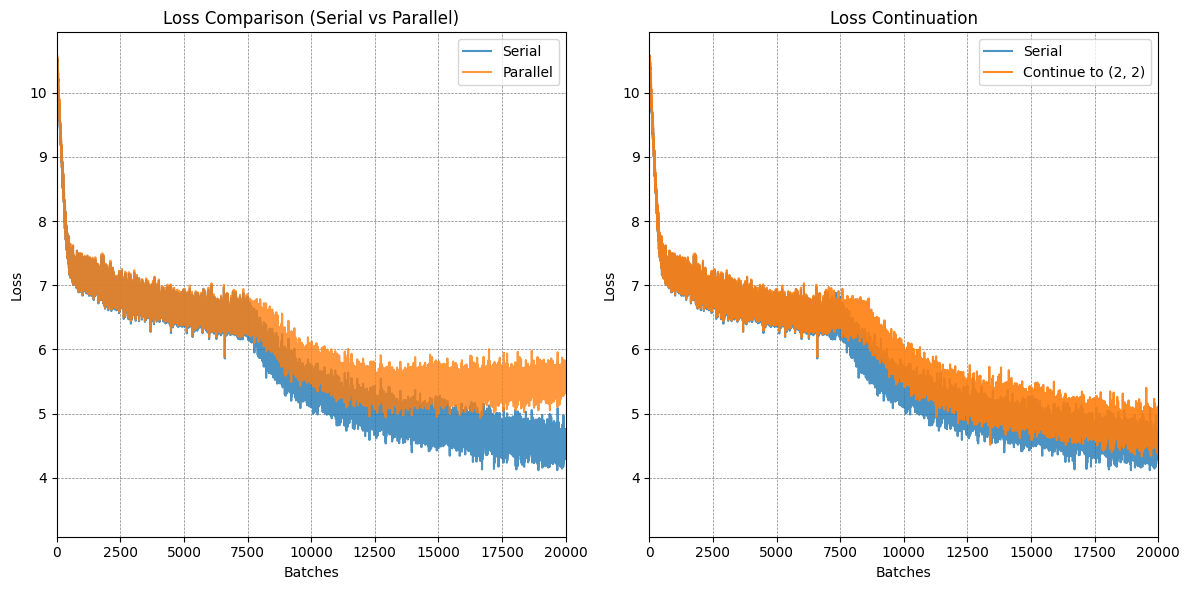

In [21]:

# Load data
log_file_path = 'exp_5/ml_multi_4-serial.out'
loss_serial = read_log_file(log_file_path)

log_file_path = 'exp_5/ml_multi_4-parallel.out'
loss_parallel = read_log_file(log_file_path)

log_file_path = 'ml_multi_4-22-serial.out'
loss_continue_22 = read_log_file(log_file_path)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot on the left side (axes[0])
axes[0].plot(np.arange(len(loss_serial)), loss_serial, alpha=0.8)
axes[0].plot(np.arange(len(loss_serial)), loss_parallel[:len(loss_serial)], alpha=0.8)
axes[0].set_title('Loss Comparison (Serial vs Parallel)')
axes[0].set_xlabel('Batches')
axes[0].set_ylabel('Loss')
axes[0].legend(['Serial', 'Parallel'])
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0].set_xlim(0, 20000)


# Plot on the right side (axes[1])
# First create right side data
offset = 7000
skip = 200
p_and_s = np.concat((loss_parallel[0:offset], loss_continue_22[skip:]))
axes[1].plot(np.arange(len(loss_serial)), loss_serial, alpha=0.8)
axes[1].plot(np.arange(len(p_and_s)),p_and_s, alpha=0.9)
axes[1].set_title('Loss Continuation')
axes[1].set_xlabel('Batches')
axes[1].set_ylabel('Loss')
axes[1].legend(['Serial', 'Continue to (2, 2)'])
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1].set_xlim(0, 20000)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [36]:
# loss_serial = 
offset = 7000
skip = 200
p_and_s = np.concat((loss_parallel[0:offset], loss_continue_22[skip:]))

downsample_factor = 150
batches = np.arange(len(loss_serial))
loss_serial_batches = batches[::downsample_factor]
loss_serial_downsampled = loss_serial[::downsample_factor]

batches = np.arange(len(loss_parallel))
loss_parallel_batches = batches[::downsample_factor]
loss_parallel_downsampled = loss_parallel[::downsample_factor]

batches = np.arange(len(p_and_s))
p_and_s_batches = batches[::downsample_factor]
p_and_s_downsampled = p_and_s[::downsample_factor]


# Export loss_serial to CSV
loss_serial_data = np.column_stack((loss_serial_batches, loss_serial_downsampled))
np.savetxt("loss_serial.csv", loss_serial_data, delimiter=",", header="Batches,loss_serial", comments="")

loss_parallel_data = np.column_stack((loss_parallel_batches, loss_parallel_downsampled))
np.savetxt("loss_parallel.csv", loss_parallel_data, delimiter=",", header="Batches,loss_parallel", comments="")

p_and_s_data = np.column_stack((p_and_s_batches, p_and_s_downsampled))
np.savetxt("p_and_s.csv", p_and_s_data, delimiter=",", header="Batches,p_and_s", comments="")



In [34]:
len(loss_serial_downsampled)

275

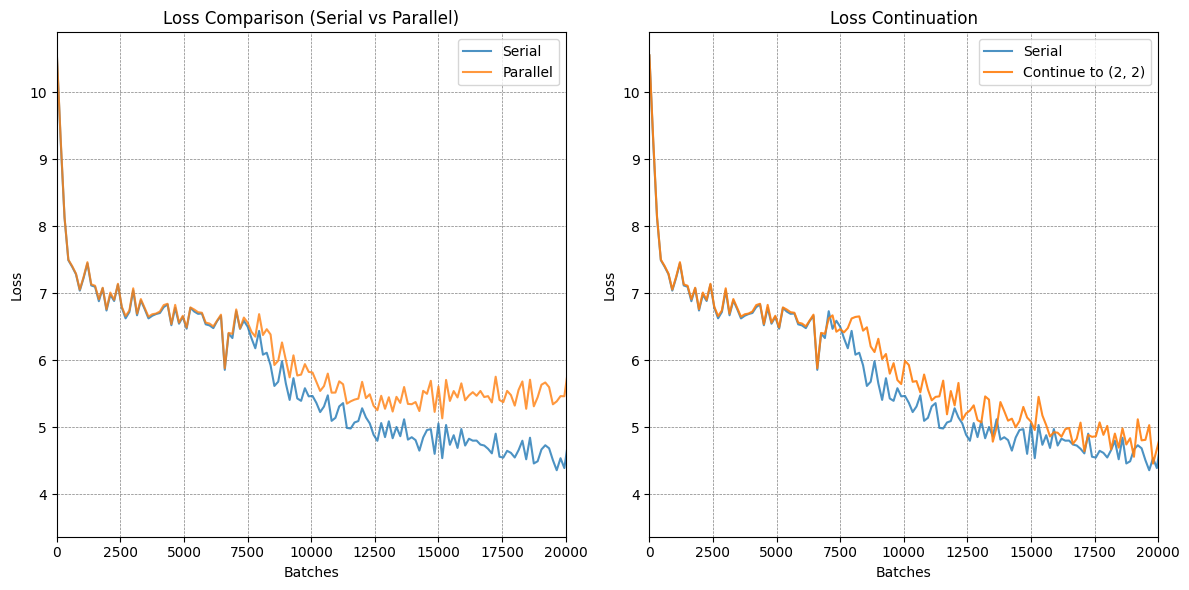

In [35]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot on the left side (axes[0])
axes[0].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[0].plot(loss_parallel_batches, loss_parallel_downsampled, alpha=0.8)
axes[0].set_title('Loss Comparison (Serial vs Parallel)')
axes[0].set_xlabel('Batches')
axes[0].set_ylabel('Loss')
axes[0].legend(['Serial', 'Parallel'])
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0].set_xlim(0, 20000)


# Plot on the right side (axes[1])
# First create right side data
axes[1].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[1].plot(p_and_s_batches,p_and_s_downsampled, alpha=0.9)
axes[1].set_title('Loss Continuation')
axes[1].set_xlabel('Batches')
axes[1].set_ylabel('Loss')
axes[1].legend(['Serial', 'Continue to (2, 2)'])
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1].set_xlim(0, 20000)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


BERT
- (2, 2) -> (1, 1), works well
- (3, 3) -> (2, 2) (very few on (2, 2)) -> serial
- (3, 3) -> (1, 1), todo and save 
- New parallel framework; (3, 3) -> (2, 2) -> (1, 1); got the value of (3, 3) residual; save into exp_7 folder; ~4500 batches is the limit; currently running the (2, 2)
- Finetuning the final models (bottleneck on some of the GLUE benchmarks: need final triained for serial (done) and parallel (still working on the (3,3) -> (2, 2) -> (1, 1))
- Timing data with multi level (3, 3), and much higher # of layers (256); should be easy... will take some time to get "largest batch" for the 256 case but 128 and (2, 2) case are known already.
  
- New weird bug: going from (2, 2) -> (1, 1) with EVERYTHING results in ~200 iterations of weird things; i tried turning the learning rate super low but maybe
    - To test: try continuing with SAME level and see if it comes with the same problem; if so then something funky going on

VIT
- Figure out how to 1. download imagenet and process data
- 2. Figure out some training method which converges somewhat well; see plots and residuals